In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
!nvidia-smi

Mon Jun 22 17:53:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install --upgrade keras opencv-python-headless

import os
import keras
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report

print(f"Using Keras version: {keras.__version__}")
print(f"Backend framework: {keras.backend.backend()}")


In [ ]:
TRAIN_DIR = '/content/drive/MyDrive/BabyNest/dataset_images/train'
VAL_DIR = '/content/drive/MyDrive/BabyNest/dataset_images/val'
TEST_DIR = '/content/drive/MyDrive/BabyNest/dataset_images/test'

# Model destination path
MODEL_SAVE_PATH = '/content/drive/MyDrive/BabyNest/babynest_model.keras'

# !!! REPLACE 'YOUR_CLASS_FOLDER/YOUR_IMAGE.jpg' !!!
# Go to your test folder, pick an image (e.g., 'crying/baby_01.jpg'), and paste it here

TEST_IMAGE_FOR_XAI = '/content/drive/MyDrive/BabyNest/dataset_images/test/cry/Supine_2_jpg.rf.bef005dd76d28510221272638311b05d.jpg'

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16  # Low batch size maintains stable CPU RAM management

print("\n--- Loading All Three Dataset Splits ---")
train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR, label_mode='categorical', image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True
)

val_ds = keras.utils.image_dataset_from_directory(
    VAL_DIR, label_mode='categorical', image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
)

test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR, label_mode='categorical', image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"\nClasses discovered: {class_names}")

# Prefetch optimization streams data to the CPU efficiently using your fix
train_ds = train_ds.prefetch(buffer_size=-1)
val_ds = val_ds.prefetch(buffer_size=-1)
test_ds = test_ds.prefetch(buffer_size=-1)


--- Loading All Three Dataset Splits ---


NameError: name 'TRAIN_DIR' is not defined

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

# ==========================================
# STEP 4: MODEL CONFIGURATION (With In-Model Augmentation)
# ==========================================
num_classes = len(class_names)

print("\n--- Initializing EfficientNetB0 Backbone ---")
base_model = keras.applications.EfficientNetB0(
    weights='imagenet', include_top=False, input_shape=(224, 224, 3), pooling='avg'
)
base_model.trainable = False  # Keep backbone locked for quick CPU processing

# Data Augmentation layers appended inside the model structure
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.15),
    keras.layers.RandomBrightness(0.2),
])

inputs = keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)  # Automatically deactivated by Keras during evaluation mode!
x = keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)

x = keras.layers.Dense(256, activation='relu')(x)
x = keras.layers.Dropout(0.3)(x)  # Dropout helps push past the 80% accuracy limit
outputs = keras.layers.Dense(num_classes, activation='softmax')(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-2),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n--- Starting Training Loop (Monitoring Val Loss) ---")
epochs = 10
history = model.fit(train_ds, validation_data=val_ds, epochs=epochs)

# ==========================================
# STEP 5: SAVE MODEL FOR VS CODE
# ==========================================
print("\n--- Exporting Native Model Asset ---")
model.save(MODEL_SAVE_PATH)
print(f"Model saved successfully to: {MODEL_SAVE_PATH}")

# ==========================================
# STEP 6: PLOTTING METRICS & LOSS CURVES
# ==========================================
print("\n--- Generating Training vs Validation Curves ---")
plt.figure(figsize=(14, 5))

# Loss Curves
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], 'b-', label='Train Loss')
plt.plot(history.history['val_loss'], 'r-', label='Val Loss')
plt.title('BabyNest Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy Curves
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], 'g-', label='Train Acc')
plt.plot(history.history['val_accuracy'], 'm-', label='Val Acc')
plt.title('BabyNest Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================================
# STEP 7: UNBIASED EVALUATION ON THE TEST SPLIT
# ==========================================
print("\n--- Running Final Evaluation on Hidden Test Dataset ---")
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\n>> Final Unseen Test Accuracy: {test_acc*100:.2f}% <<")

# Collect true and predicted labels strictly from the unseen Test set for the confusion matrix
all_preds = []
all_labels = []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    all_preds.extend(np.argmax(preds, axis=1))
    all_labels.extend(np.argmax(labels.numpy(), axis=1))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=class_names, yticklabels=class_names)
plt.title('BabyNest Final Test Confusion Matrix')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

print("\nFinal Test Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))


In [ ]:
print("\n--- Resuming Training: Epochs 11 to 20 ---")

# Train for 10 more epochs on top of the saved weights
extended_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# Re-save the updated model back to your Google Drive
model.save(MODEL_SAVE_PATH)
print(f"Updated model successfully saved to: {MODEL_SAVE_PATH}")


--- Resuming Training: Epochs 11 to 20 ---
Epoch 1/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 157s 437ms/step - accuracy: 0.8618 - loss: 0.3901 - val_accuracy: 0.8715 - val_loss: 0.3801
Epoch 2/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 141s 394ms/step - accuracy: 0.8682 - loss: 0.3800 - val_accuracy: 0.8910 - val_loss: 0.3484
Epoch 3/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 173s 484ms/step - accuracy: 0.8784 - loss: 0.3543 - val_accuracy: 0.8887 - val_loss: 0.3525
Epoch 4/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 142s 397ms/step - accuracy: 0.8835 - loss: 0.3401 - val_accuracy: 0.8901 - val_loss: 0.3441
Epoch 5/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 141s 395ms/step - accuracy: 0.8800 - loss: 0.3371 - val_accuracy: 0.8892 - val_loss: 0.3433
Epoch 6/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 130s 363ms/step - accuracy: 0.8886 - loss: 0.3260 - val_accuracy: 0.9019 - val_loss: 0.3207
Epoch 7/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 130s 365ms/step - accuracy: 0.8975 - loss: 0.3062 - val_accuracy: 0.9019 - val_loss: 0.3217
Epoch 8/10
357/357 ━━━━━━━━━━━━━


--- Generating New Training vs Validation Curves (Epochs 11 to 20) ---


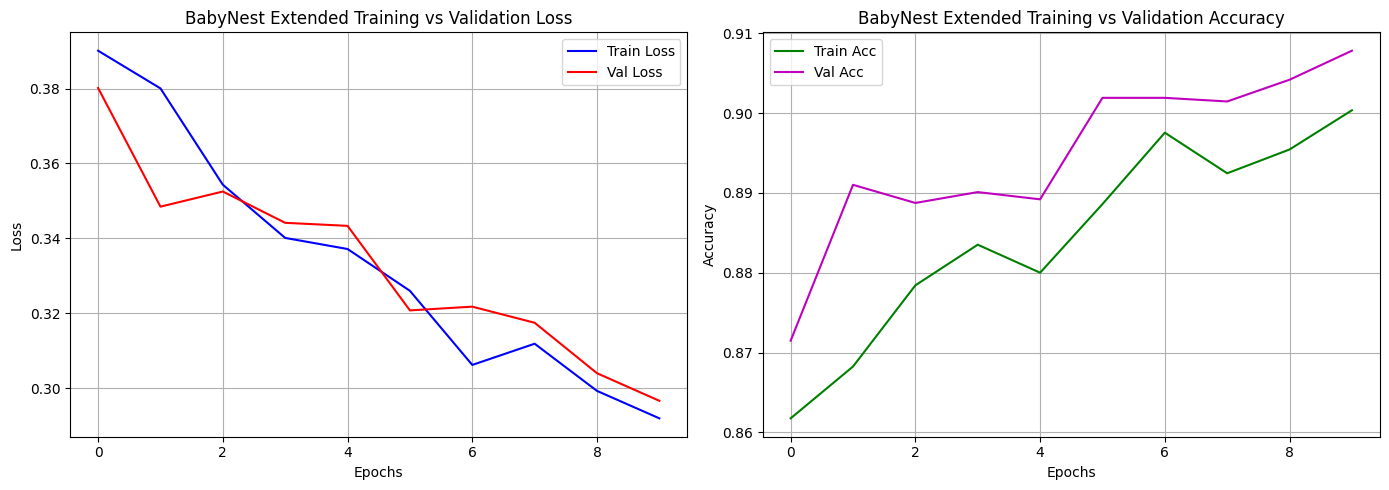


--- Running Final Evaluation on Hidden Test Dataset ---
163/163 ━━━━━━━━━━━━━━━━━━━━ 41s 251ms/step - accuracy: 0.8846 - loss: 0.3344

>> Updated Unseen Test Accuracy: 88.46% <<


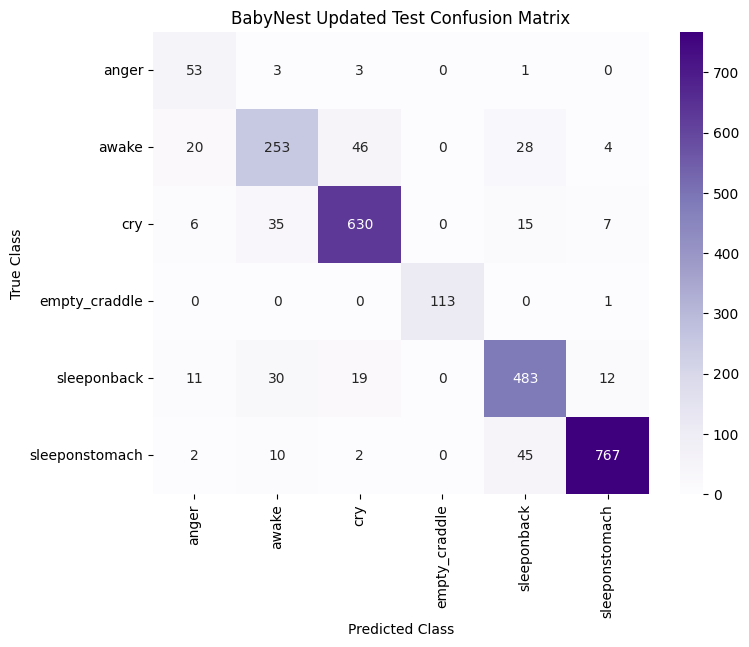


Updated Test Classification Report:

                precision    recall  f1-score   support

         anger       0.58      0.88      0.70        60
         awake       0.76      0.72      0.74       351
           cry       0.90      0.91      0.90       693
 empty_craddle       1.00      0.99      1.00       114
   sleeponback       0.84      0.87      0.86       555
sleeponstomach       0.97      0.93      0.95       826

      accuracy                           0.88      2599
     macro avg       0.84      0.88      0.86      2599
  weighted avg       0.89      0.88      0.89      2599



In [ ]:
print("\n--- Generating New Training vs Validation Curves (Epochs 11 to 20) ---")
plt.figure(figsize=(14, 5))

# 1. Loss Curves
plt.subplot(1, 2, 1)
plt.plot(extended_history.history['loss'], 'b-', label='Train Loss')
plt.plot(extended_history.history['val_loss'], 'r-', label='Val Loss')
plt.title('BabyNest Extended Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 2. Accuracy Curves
plt.subplot(1, 2, 2)
plt.plot(extended_history.history['accuracy'], 'g-', label='Train Acc')
plt.plot(extended_history.history['val_accuracy'], 'm-', label='Val Acc')
plt.title('BabyNest Extended Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 3. New Evaluation on the Hidden Test Dataset
print("\n--- Running Final Evaluation on Hidden Test Dataset ---")
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\n>> Updated Unseen Test Accuracy: {test_acc*100:.2f}% <<")

# 4. Generate New Confusion Matrix
all_preds = []
all_labels = []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    all_preds.extend(np.argmax(preds, axis=1))
    all_labels.extend(np.argmax(labels.numpy(), axis=1))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=class_names, yticklabels=class_names)
plt.title('BabyNest Updated Test Confusion Matrix')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

print("\nUpdated Test Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

In [ ]:
import cv2
import numpy as np
import keras
from tqdm import tqdm

# 1. Configuration (Matching your notebook's pipeline)
IMG_SIZE = (224, 224)
MODEL_PATH = '/content/drive/MyDrive/BabyNest/babynest_model.keras'

# UPDATE THESE: Set your input video path and where you want to save the result
INPUT_VIDEO_PATH = '/content/drive/MyDrive/BabyNest/video3.mp4'
OUTPUT_VIDEO_PATH = '/content/drive/MyDrive/BabyNest/video18.mp4'

# Class names exactly as discovered in your dataset split
CLASS_NAMES = ['anger', 'awake', 'cry', 'empty_craddle', 'sleeponback', 'sleeponstomach']
num_classes = len(CLASS_NAMES)

# 2. Re-create the native Keras 3 architecture to bypass version conflicts safely
print("--- Building Clean Keras 3 Architecture ---")
base_model = keras.applications.EfficientNetB0(
    weights=None,  # We will load your trained weights instead of imagenet
    include_top=False,
    input_shape=(224, 224, 3),
    pooling='avg'
)

# Mirroring your original sequential layers setup
inputs = keras.Input(shape=(224, 224, 3))
x = keras.applications.efficientnet.preprocess_input(inputs)
x = base_model(x, training=False)
x = keras.layers.Dense(256, activation='relu')(x)
x = keras.layers.Dropout(0.3)(x)
outputs = keras.layers.Dense(num_classes, activation='softmax')(x)
model = keras.Model(inputs, outputs)

# 3. Load only your trained weights from Google Drive
print("--- Injecting Your Trained Weights ---")
model.load_weights(MODEL_PATH)

# 4. Open the input video from Drive
cap = cv2.VideoCapture(INPUT_VIDEO_PATH)
if not cap.isOpened():
    raise ValueError(f"Error: Could not open input video at {INPUT_VIDEO_PATH}. Check the filename!")

# Get video properties for the exporter
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# 5. Initialize the Video Writer to save the output back to Drive
fourcc = cv2.VideoWriter_fourcc(*'mp4v') # Codec for .mp4 formats
out = cv2.VideoWriter(OUTPUT_VIDEO_PATH, fourcc, fps, (width, height))

print(f"--- Processing Video ({total_frames} frames) ---")

# Loop through every frame with a progress bar
for _ in tqdm(range(total_frames)):
    ret, frame = cap.read()
    if not ret:
        break

    # Preprocess the frame for EfficientNetB0 (BGR to RGB -> Resize -> Batch Expand)
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    resized_frame = cv2.resize(rgb_frame, IMG_SIZE)
    input_tensor = np.expand_dims(resized_frame, axis=0)

    # Run Prediction
    predictions = model.predict(input_tensor, verbose=0)
    score = predictions[0]

    predicted_class_idx = np.argmax(score)
    predicted_label = CLASS_NAMES[predicted_class_idx]
    confidence = score[predicted_class_idx] * 100

    # Handle the "Laughing" situation mapping
    if predicted_label == 'awake':
        display_text = f"Status: Awake/Active ({confidence:.1f}%)"
        color = (0, 255, 0)  # Green
    elif predicted_label in ['cry', 'anger']:
        display_text = f"Status: ALERT - {predicted_label.upper()} ({confidence:.1f}%)"
        color = (0, 0, 255)  # Red
    elif predicted_label in ['sleeponback', 'sleeponstomach']:
        display_text = f"Status: Sleeping ({confidence:.1f}%)"
        color = (255, 0, 0)  # Blue
    else:
        display_text = f"Status: {predicted_label} ({confidence:.1f}%)"
        color = (255, 255, 255) # White

    # Draw background box for text legibility
    cv2.rectangle(frame, (20, 20), (550, 75), (0, 0, 0), -1)
    # Write the prediction over the video frame
    cv2.putText(frame, display_text, (30, 55),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2, cv2.LINE_AA)

    # Write the modified frame into our new output file
    out.write(frame)

# Clean up files
cap.release()
out.release()
print(f"\n--- Success! Processed video saved to Google Drive at: {OUTPUT_VIDEO_PATH} ---")

--- Building Clean Keras 3 Architecture ---
--- Injecting Your Trained Weights ---
--- Processing Video (180 frames) ---


100%|██████████| 180/180 [00:24<00:00,  7.31it/s]


--- Success! Processed video saved to Google Drive at: /content/drive/MyDrive/BabyNest/video18.mp4 ---
